In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
from pathlib import Path

# Resolve A1 from the repository root, A1, notebooks, or another A1 subfolder.
for base in (Path.cwd(), *Path.cwd().parents):
    if (base / "A1" / "src" / "DataCleaner.py").is_file():
        PROJECT_DIR = base / "A1"
        break
    if (base / "src" / "DataCleaner.py").is_file():
        PROJECT_DIR = base
        break
else:
    raise FileNotFoundError("Open the notebook from within the capstone repository.")

RAW_DATA_PATH = PROJECT_DIR / "data" / "raw" / "electricity_raw.parquet"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures"

df = pd.read_parquet(RAW_DATA_PATH, engine="pyarrow")
df_clean = df.copy() # Save a working copy

# Verify load
df.head()

,timestamp,curtailment,curtailment_energy,curtailment_solar_utility,curtailment_solar_utility_energy,curtailment_wind,curtailment_wind_energy,demand,demand_energy,demand_gross,demand_gross_energy,flow_exports,flow_exports_energy,flow_imports,flow_imports_energy,generation_renewable,generation_renewable_energy,generation_renewable_with_storage,generation_renewable_with_storage_energy,price,renewable_proportion,renewable_with_storage_proportion,emissions,energy,market_value,power,storage_battery
0,2000-01-01 00:00:00+10:00,0.0,0.0,0.0,0.0,0.0,0.0,6920.580,NaN,6920.580,NaN,NaN,NaN,NaN,NaN,162.083333,0.1623,162.083333,0.1623,20.180,14.05,14.05,6200.4981,6911.5833,139546.6626,6904.166667,NaN
1,2000-01-01 01:00:00+10:00,0.0,0.0,0.0,0.0,0.0,0.0,6847.860,NaN,6847.860,NaN,NaN,NaN,NaN,NaN,163.500000,0.1637,163.500000,0.1637,17.240,14.33,14.33,5615.3196,6293.2088,109020.1868,6241.166667,NaN
2,2000-01-01 02:00:00+10:00,0.0,0.0,0.0,0.0,0.0,0.0,6188.450,NaN,6188.450,NaN,NaN,NaN,NaN,NaN,162.833333,0.1629,162.833333,0.1629,14.180,15.79,15.79,4804.7439,5401.3333,76571.5262,5374.916667,NaN
3,2000-01-01 03:00:00+10:00,0.0,0.0,0.0,0.0,0.0,0.0,5469.910,NaN,5469.910,NaN,NaN,NaN,NaN,NaN,113.583333,0.1162,113.583333,0.1162,14.225,12.46,12.46,4020.3997,4491.4584,63901.7836,4460.333333,NaN
4,2000-01-01 04:00:00+10:00,0.0,0.0,0.0,0.0,0.0,0.0,4948.025,NaN,4948.025,NaN,NaN,NaN,NaN,NaN,103.166667,0.1031,103.166667,0.1031,8.150,12.51,12.51,3700.2430,4142.1667,33845.7011,4135.583333,NaN


In [3]:
# --- Dataset Overview ---------------------------------------------
rows, cols = (df.shape)
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 234312
Columns: 27


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234312 entries, 0 to 234311
Data columns (total 27 columns):
 #   Column                                    Non-Null Count   Dtype                    
---  ------                                    --------------   -----                    
 0   timestamp                                 234312 non-null  datetime64[us, UTC+10:00]
 1   curtailment                               234312 non-null  float64                  
 2   curtailment_energy                        234312 non-null  float64                  
 3   curtailment_solar_utility                 234312 non-null  float64                  
 4   curtailment_solar_utility_energy          234312 non-null  float64                  
 5   curtailment_wind                          234312 non-null  float64                  
 6   curtailment_wind_energy                   234312 non-null  float64                  
 7   demand                                    234302 non-null  float64                  


In [5]:
# --- Descriptive Stats ---------------------------------------------
df.describe()

,curtailment,curtailment_energy,curtailment_solar_utility,curtailment_solar_utility_energy,curtailment_wind,curtailment_wind_energy,demand,demand_energy,demand_gross,demand_gross_energy,flow_exports,flow_exports_energy,flow_imports,flow_imports_energy,generation_renewable,generation_renewable_energy,generation_renewable_with_storage,generation_renewable_with_storage_energy,price,renewable_proportion,renewable_with_storage_proportion,emissions,energy,market_value,power,storage_battery
count,234312.000000,234312.000000,234312.000000,234312.000000,234312.000000,234312.000000,234302.000000,188274.000000,223780.000000,177745.000000,151041.000000,151041.000000,151041.000000,151041.000000,233860.000000,233860.000000,233860.000000,233860.000000,234312.000000,223780.000000,223780.000000,234303.000000,234303.000000,2.343030e+05,234303.000000,9232.000000
mean,23.961694,23.961692,21.033856,21.033855,2.927839,2.927837,8137.022095,8135.264833,8475.390955,8559.568025,114.083220,114.082781,864.351520,864.342955,932.854624,909.352009,1032.569713,1007.722224,62.331683,14.836233,16.841757,6183.680619,7871.629473,5.247504e+05,7871.425236,121.503231
std,139.595856,139.574384,124.644419,124.629062,25.058733,25.037319,1394.176119,1419.541371,1392.822511,1408.918037,180.493866,180.493536,461.213413,461.209012,1386.975390,1392.725095,1425.756903,1433.436730,209.292699,18.858818,20.044789,1489.876865,1557.384155,2.203313e+06,1554.662755,76.800621
min,-65.397000,-65.397600,-65.397000,-65.397600,-25.700983,-27.627000,2577.155833,600.271700,4650.365000,1241.142500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-328.295833,0.000000,0.000000,1240.989800,3202.845500,-3.499110e+06,3202.845942,3.994178
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7103.155625,7078.374150,7459.442360,7515.960000,0.000000,0.000000,531.697510,531.697510,148.084280,123.359950,212.992348,186.008900,25.005000,2.690000,3.820000,5129.143500,6742.887800,1.897122e+05,6747.079413,68.056460
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8082.064167,8051.718400,8462.742916,8520.786100,7.038117,7.038117,839.750000,839.748311,459.467512,428.922550,563.788950,532.438200,39.163155,7.820000,9.410000,6216.815700,7892.895300,3.085824e+05,7895.292500,102.201604
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9086.613333,9106.220225,9370.938161,9467.944200,180.807218,180.807218,1158.222007,1158.205322,1048.111866,1005.553400,1182.052379,1146.654950,66.452515,19.000000,21.400000,7300.902750,8953.247900,5.283934e+05,8950.745138,162.802063
max,3503.327600,3474.199700,3318.139467,3279.008000,1314.630875,1319.542000,14524.884167,14530.037100,16134.240858,16151.025100,1546.858323,1546.858323,2848.250000,2848.250000,10898.422467,10895.759200,11477.422475,11474.729900,16157.503333,231.900000,233.080000,10798.487600,16457.483800,1.672426e+08,16412.192367,441.555112


In [6]:
missing_summary = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(4),
})

display(missing_summary.sort_values("Missing (%)", ascending=False))

,Missing count,Missing (%)
storage_battery,225080,96.0600
flow_exports,83271,35.5385
flow_imports_energy,83271,35.5385
flow_exports_energy,83271,35.5385
flow_imports,83271,35.5385
demand_gross_energy,56567,24.1417
demand_energy,46038,19.6482
renewable_proportion,10532,4.4949
demand_gross,10532,4.4949
renewable_with_storage_proportion,10532,4.4949


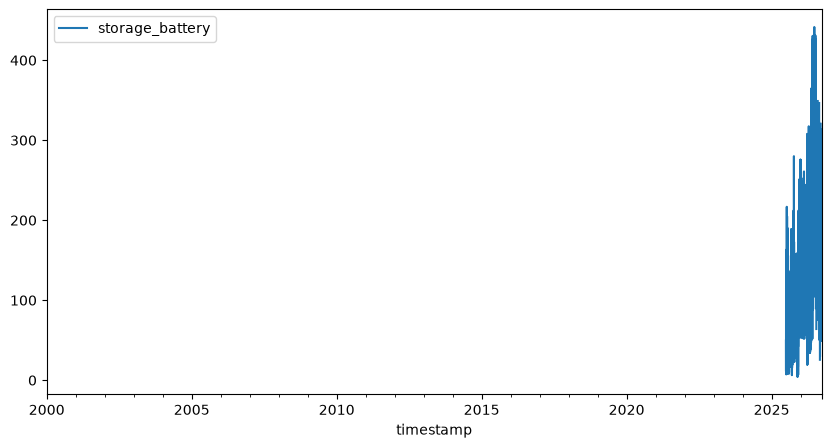

In [7]:
# Plot a single specific column against time
df.plot(kind='line', x='timestamp', y='storage_battery', figsize=(10, 5))
plt.show()

In [8]:
first_timestamp = df.loc[
    df["storage_battery"].notna(),
    "timestamp"
].min()

print("First battery observation:", first_timestamp)

First battery observation: 2025-06-30 04:00:00+10:00


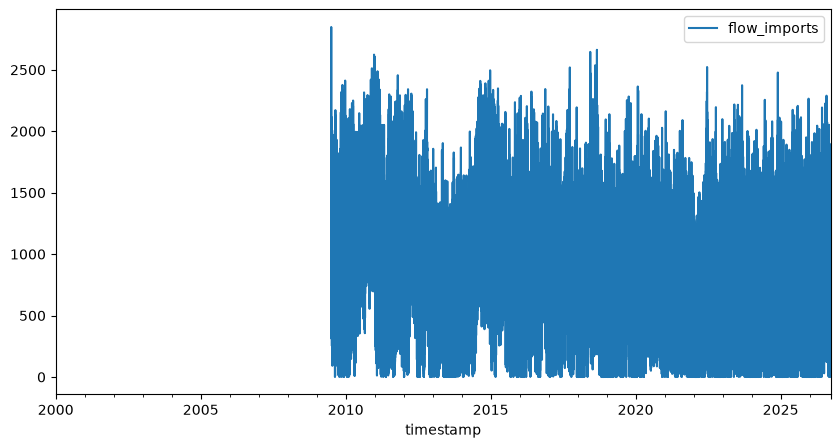

First flow_imports observation: 2009-07-01 00:00:00+10:00


In [9]:
df.plot(kind='line', x='timestamp', y='flow_imports', figsize=(10, 5))
plt.show()

first_timestamp = df.loc[
    df["flow_imports"].notna(),
    "timestamp"
].min()

print("First flow_imports observation:", first_timestamp)

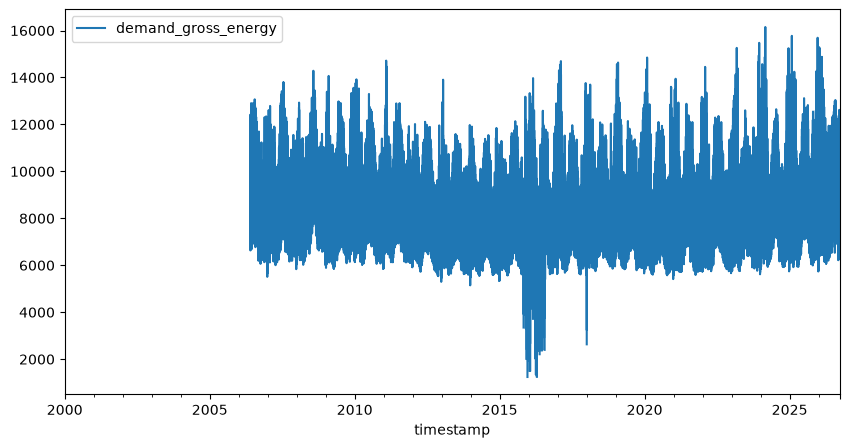

First demand_gross_energy observation: 2006-05-27 00:00:00+10:00


In [10]:
df.plot(kind='line', x='timestamp', y='demand_gross_energy', figsize=(10, 5))
plt.show()

first_timestamp = df.loc[
    df["demand_gross_energy"].notna(),
    "timestamp"
].min()

print("First demand_gross_energy observation:", first_timestamp)

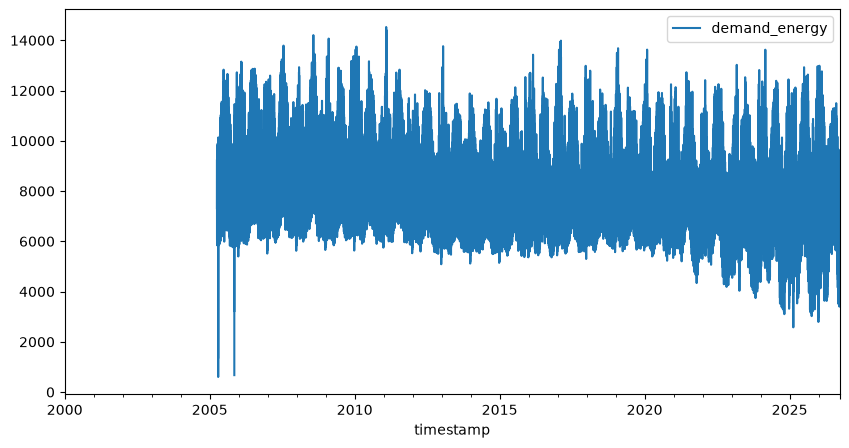

First demand_energy observation: 2005-04-01 10:00:00+10:00


In [11]:
df.plot(kind='line', x='timestamp', y='demand_energy', figsize=(10, 5))
plt.show()

first_timestamp = df.loc[
    df["demand_energy"].notna(),
    "timestamp"
].min()

print("First demand_energy observation:", first_timestamp)

In [12]:
# Missing energy
df.loc[
    df["energy"].isna(),
    ["timestamp", "energy"]
]

,timestamp,energy
5738,2000-08-27 02:00:00+10:00,NaN
15986,2001-10-28 02:00:00+10:00,NaN
24722,2002-10-27 02:00:00+10:00,NaN
33458,2003-10-26 02:00:00+10:00,NaN
42362,2004-10-31 02:00:00+10:00,NaN
51098,2005-10-30 02:00:00+10:00,NaN
59834,2006-10-29 02:00:00+10:00,NaN
68570,2007-10-28 02:00:00+10:00,NaN
76802,2008-10-05 02:00:00+10:00,NaN


In [13]:
# Missing Demand
df.loc[
    df["demand"].isna(),
    ["timestamp", "demand"]
]

,timestamp,demand
5738,2000-08-27 02:00:00+10:00,NaN
14688,2001-09-04 00:00:00+10:00,NaN
15986,2001-10-28 02:00:00+10:00,NaN
24722,2002-10-27 02:00:00+10:00,NaN
33458,2003-10-26 02:00:00+10:00,NaN
42362,2004-10-31 02:00:00+10:00,NaN
51098,2005-10-30 02:00:00+10:00,NaN
59834,2006-10-29 02:00:00+10:00,NaN
68570,2007-10-28 02:00:00+10:00,NaN
76802,2008-10-05 02:00:00+10:00,NaN


Rows with missing energy or demand were retained to preserve the hourly timeline and other valid measurements. Unavailable values were left as NaN.

In [14]:
# Duplicated rows / timestamps
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Duplicated timestamp: {df["timestamp"].duplicated().sum()}")

Duplicated rows: 0
Duplicated timestamp: 0


In [15]:
# --- Coverage Investigation  ---------------------------------------------
ts = pd.DatetimeIndex(df["timestamp"]).sort_values()

expected = pd.date_range(ts.min(), ts.max(), freq="h")
missing_hours = expected.difference(ts)

print("Expected hourly rows:", len(expected))
print("Missing hours:", len(missing_hours))
display(missing_hours[:48])

Expected hourly rows: 234312
Missing hours: 0


DatetimeIndex([], dtype='datetime64[us, UTC+10:00]', freq='h')

The original fetch code skipped one day between requests, omitting 7,320 hourly timestamps. The next request now starts at the previous request’s end, with repeated boundary observations handled explicitly. After refetching, all 234,312 expected hourly timestamps are present.

In [16]:
monthly_missing = (
    df.set_index("timestamp")
      .sort_index()
      .asfreq("h")
      .isna()
      .resample("MS")
      .mean()
      .mul(100)
)

display(
    monthly_missing[
        ["energy", "demand", "flow_imports", "storage_battery"]
    ].tail(24).round(2)
)

,energy,demand,flow_imports,storage_battery
timestamp,,,,
2024-10-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2024-11-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2024-12-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-01-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-02-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-03-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-04-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-05-01 00:00:00+10:00,0.0,0.0,0.0,100.00
2025-06-01 00:00:00+10:00,0.0,0.0,0.0,97.22


### Coverage decisions

Missing historical imports and battery observations remain `NaN`; they are not assumed to be zero. Battery coverage is complete in several months after June 2025 but becomes sparse again in 2026 (82.26% missing in August). The cause remains unverified, and these gaps are retained in the cleaned output.

Monthly percentages cover only timestamps within the dataset. September 2026 ends on September 23, so its percentage is for a partial month.

Pre-September-2020 curtailment zeros are retained as source values, but must not be interpreted as verified absence of curtailment: the underlying fields only became available in September 2020 according to the [Open Electricity changelog](https://docs.openelectricity.org.au/changelog/). Historical coverage is a limitation of the exported data; no exact cutoff conversion has been applied here.

In [17]:
# --- Consistency Checks ---------------------------------------------
suspect_proportions = df.loc[
    df["renewable_proportion"] > 100,
    [
        "timestamp",
        "renewable_proportion",
        "generation_renewable",
        "demand_gross",
    ],
]

print("Rows above 100% for renewable proportion:", len(suspect_proportions))
display(suspect_proportions.head(20))

Rows above 100% for renewable proportion: 1101


,timestamp,renewable_proportion,generation_renewable,demand_gross
233,2000-01-10 17:00:00+10:00,101.25,1103.083333,6537.030
300,2000-01-13 12:00:00+10:00,103.77,1438.250000,8316.020
301,2000-01-13 13:00:00+10:00,107.48,1492.583333,8332.385
302,2000-01-13 14:00:00+10:00,109.94,1511.083333,8247.035
303,2000-01-13 15:00:00+10:00,119.51,1635.166667,8209.575
304,2000-01-13 16:00:00+10:00,121.13,1661.666667,8230.855
305,2000-01-13 17:00:00+10:00,118.13,1614.000000,8197.805
306,2000-01-13 18:00:00+10:00,100.85,1349.250000,8026.935
323,2000-01-14 11:00:00+10:00,100.27,1429.166667,8551.990
324,2000-01-14 12:00:00+10:00,104.54,1487.750000,8538.600


### Renewable proportion decision

The 1,101 observations above 100% require source-definition and calculation verification. They are retained unchanged, not clipped to 100 or removed. This check flags suspicious observations rather than establishing a universal physical upper bound. Their cause remains unresolved, and the exported dataset still contains them.

In [18]:
# Check for a possible unit or calculation problem
ratio = (
    df["generation_renewable_energy"]
    / df["generation_renewable"].where(
        df["generation_renewable"] != 0
    )
)

display(
    ratio.groupby(df["timestamp"].dt.year)
         .median()
         .rename("Median energy/power ratio")
)

timestamp
2000    0.001000
2001    1.000007
2002    1.000027
2003    1.000011
2004    1.000025
2005    1.000035
2006    1.000026
2007    1.000008
2008    1.000018
2009    1.000044
2010    1.000148
2011    1.000119
2012    1.000177
2013    1.000084
2014    1.000289
2015    1.000319
2016    1.000171
2017    1.000333
2018    1.000232
2019    1.000259
2020    1.000247
2021    1.000274
2022    1.000367
2023    1.000300
2024    1.000498
2025    1.000470
2026    1.000883
Name: Median energy/power ratio, dtype: float64

In [19]:
# Investigate 2000 and 2001
ratio = (
    df["generation_renewable_energy"]
    / df["generation_renewable"].where(
        df["generation_renewable"] != 0
    )
)

monthly_ratio = (
    pd.DataFrame({
        "timestamp": df["timestamp"],
        "ratio": ratio,
    })
    .set_index("timestamp")["ratio"]
    .resample("MS")
    .median()
)

display(monthly_ratio.loc["2000":"2001"])

timestamp
2000-01-01 00:00:00+10:00    0.001000
2000-02-01 00:00:00+10:00    0.001000
2000-03-01 00:00:00+10:00    0.001000
2000-04-01 00:00:00+10:00    0.001000
2000-05-01 00:00:00+10:00    0.001002
2000-06-01 00:00:00+10:00    0.001003
2000-07-01 00:00:00+10:00    0.001003
2000-08-01 00:00:00+10:00    0.001003
2000-09-01 00:00:00+10:00    0.001001
2000-10-01 00:00:00+10:00    0.001001
2000-11-01 00:00:00+10:00    0.001001
2000-12-01 00:00:00+10:00    0.001000
2001-01-01 00:00:00+10:00    1.000000
2001-02-01 00:00:00+10:00    1.000000
2001-03-01 00:00:00+10:00    1.000002
2001-04-01 00:00:00+10:00    1.000015
2001-05-01 00:00:00+10:00    1.000569
2001-06-01 00:00:00+10:00    1.000349
2001-07-01 00:00:00+10:00    1.000485
2001-08-01 00:00:00+10:00    1.000101
2001-09-01 00:00:00+10:00    1.000000
2001-10-01 00:00:00+10:00    1.000012
2001-11-01 00:00:00+10:00    1.000019
2001-12-01 00:00:00+10:00    1.000027
Freq: MS, Name: ratio, dtype: float64

In [20]:
affected = df["timestamp"].dt.year.eq(2000)

df_clean.loc[affected, "generation_renewable_energy"] = (
    df.loc[affected, "generation_renewable_energy"] * 1000
)

In [21]:
comparison = {}

for name, frame in {"Before": df, "After": df_clean}.items():
    ratio = (
        frame["generation_renewable_energy"]
        / frame["generation_renewable"].where(
            frame["generation_renewable"] != 0
        )
    )

    comparison[name] = ratio.groupby(
        frame["timestamp"].dt.year
    ).median()

display(pd.DataFrame(comparison).loc[2000:2001])

,Before,After
timestamp,,
2000,0.001000,1.000420
2001,1.000007,1.000007


### Energy scaling decision

The monthly median renewable energy/power ratio is approximately 0.001 throughout 2000 and approximately 1 from 2001 onward. For matching hourly MW and MWh measurements, a ratio near one is expected, allowing for integration differences.

Open Electricity documented an erroneous division by 1,000 affecting this metric in [issue #605](https://github.com/opennem/opennem/issues/605) and [fix #606](https://github.com/opennem/opennem/pull/606). Fresh January 1 samples for 2000 and 2001 reproduce the saved values, with energy labelled MWh in both years. See [comparison results](../data/validation/energy_scale_20260928T104958038336Z/comparison.csv) and [unit metadata](../data/validation/energy_scale_20260928T104958038336Z/metadata.json).

We apply an inferred factor-of-1,000 correction to `generation_renewable_energy` for 2000 only, deriving values from the unchanged raw DataFrame so rerunning the correction does not compound it. This is supported by the observed pattern and documented upstream bug; Open Electricity has not confirmed the exact cause or affected range for these records. The before/after table is a consistency check, not independent proof of the correction.

`generation_renewable_with_storage_energy` remains unchanged pending separate verification. Users of the cleaned dataset should not assume that related energy columns have all been validated or corrected.

In [22]:
from pathlib import Path

(FIGURES_DIR / "histograms").mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / "boxplots").mkdir(parents=True, exist_ok=True)

# --- Numerical Distributions ---------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    fig = px.histogram(
        df,
        x=column,
        nbins=30,
        title=f"Raw data: distribution of {column}",
        labels={column: column},
        width=800,
        height=400
    )

    fig.update_layout(
        xaxis_title=column,
        yaxis_title="Frequency"
    )

    fig.write_html(FIGURES_DIR / "histograms" / f"{column}_distribution.html")

In [23]:
# --- Outlier Detection ---------------------------------------------

for column in numeric_columns:
    fig = px.box(
        df,
        x=column,
        title=f"Raw data: boxplot of {column}"
    )

    fig.write_html(FIGURES_DIR / "boxplots" / f"{column}_boxplot.html")

In [24]:
negative_curtailment = df[df["curtailment"] < 0]

print("Negative values:", len(negative_curtailment))
print(negative_curtailment["curtailment"].describe())
print(negative_curtailment["curtailment"].sort_values().head(20))

fig = px.histogram(
    df[df["curtailment"] < 0],
    x="curtailment",
    nbins=50,
    title="Distribution of Negative Curtailment Values"
)

fig.show()

Negative values: 1157
count    1157.000000
mean       -1.904616
std         3.944118
min       -65.397000
25%        -2.044842
50%        -0.852150
75%        -0.297750
max        -0.000600
Name: curtailment, dtype: float64
196914   -65.397000
196913   -65.246350
196912   -49.420233
186520   -20.301125
226254   -19.502217
201904   -18.312567
231489   -17.457375
183367   -17.388275
211216   -16.848392
201401   -16.570275
181696   -16.046817
211217   -14.843358
186608   -14.265225
183368   -13.255800
186496   -13.162108
186112   -12.854133
196886   -12.198917
186494   -11.770392
183369   -11.396575
196915   -11.349250
Name: curtailment, dtype: float64


In [25]:
df.loc[
    df["curtailment"] < -10,
    ["timestamp", "curtailment"]
].sort_values("curtailment")

,timestamp,curtailment
196914,2022-06-18 18:00:00+10:00,-65.397000
196913,2022-06-18 17:00:00+10:00,-65.246350
196912,2022-06-18 16:00:00+10:00,-49.420233
186520,2021-04-11 16:00:00+10:00,-20.301125
226254,2025-10-23 06:00:00+10:00,-19.502217
201904,2023-01-12 16:00:00+10:00,-18.312567
231489,2026-05-29 09:00:00+10:00,-17.457375
183367,2020-12-01 07:00:00+10:00,-17.388275
211216,2024-02-04 16:00:00+10:00,-16.848392
201401,2022-12-22 17:00:00+10:00,-16.570275


### Negative curtailment decision

The refreshed dataset contains 1,157 negative curtailment observations (median approximately -0.852 MW; minimum -65.397 MW). Negative values were investigated and retained as reported; the sign alone does not establish a corrupt measurement. No clipping or predictive curtailment features are applied in this cleaning notebook.

In [26]:
# --- Validation and Export ---------------------------------------------
df_clean = df_clean.sort_values("timestamp").reset_index(drop=True)

assert df_clean["timestamp"].notna().all()
assert df_clean["timestamp"].is_unique
assert df_clean["timestamp"].is_monotonic_increasing

display(pd.DataFrame({
    "Missing before": df.isna().sum(),
    "Missing after": df_clean.isna().sum(),
}))

,Missing before,Missing after
timestamp,0,0
curtailment,0,0
curtailment_energy,0,0
curtailment_solar_utility,0,0
curtailment_solar_utility_energy,0,0
curtailment_wind,0,0
curtailment_wind_energy,0,0
demand,10,10
demand_energy,46038,46038
demand_gross,10532,10532


In [27]:
from pathlib import Path

output_dir = PROCESSED_DIR
output_dir.mkdir(parents=True, exist_ok=True)

df_clean.to_parquet(
    output_dir / "electricity_cleaned.parquet",
    engine="pyarrow",
    index=False,
)